## [1] 이미지 준비

In [39]:
#--------------------------------------
# 이미지 다운로드
#--------------------------------------------
import requests

# 이미지 URL
image_url = "https://raw.githubusercontent.com/pjm9889/DeepLearning/main/data/G_sample.png"

# 로컬 파일 이름 설정
file_name = "sample.png"

# 이미지 다운로드 요청
response = requests.get(image_url)

# 다운로드 성공 여부 확인
if response.status_code == 200:
    # 이미지를 로컬 파일로 저장
    with open(file_name, "wb") as f:
        f.write(response.content)
    print("이미지가 성공적으로 저장되었습니다.")
else:
    print("이미지를 다운로드하는 데 문제가 발생했습니다. 상태 코드:", response.status_code)

이미지가 성공적으로 저장되었습니다.


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

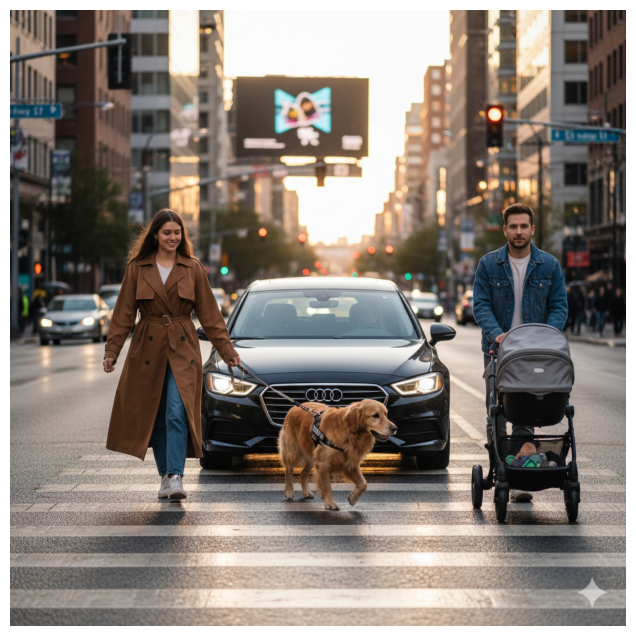

In [40]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")

## [2] openCV의 selectiveSearchSegmentation 모듈활용

In [41]:
import cv2

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchQuality()   # 논문 버전: 고품질

rects = ss.process()   # (x, y, w, h) 형식
print("ROI 개수:", len(rects))


ROI 개수: 33598


In [42]:
rects[:5]

array([[924, 728,   9,  27],
       [282, 476,  26,  19],
       [282, 762, 490,  95],
       [ 50, 557, 109,  61],
       [ 65,  10,   5,  56]], dtype=int32)

## [3] CNN

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class MiniCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32*56*56, 2)  # 예: 2클래스 가정

    def forward(self, x):
        x = self.feature(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = MiniCNN()


In [46]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [50]:
# 에러는 다 실행되지 않게 하느라, 중단하여서 생성된 거
proposals = []

for (x, y, w, h) in rects:   # 너무 많으므로 상위 200개만
    crop = img_rgb[y:y+h, x:x+w]
    if crop.size == 0:
        continue

    input_tensor = transform(crop).unsqueeze(0)
    with torch.no_grad():
        out = model(input_tensor)
        score = torch.softmax(out,1)[0][1].item()  # class1 확률

    if score > 0.5:
        proposals.append((x, y, x+w, y+h, score))

print("검출된 박스:", len(proposals))


KeyboardInterrupt: 

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

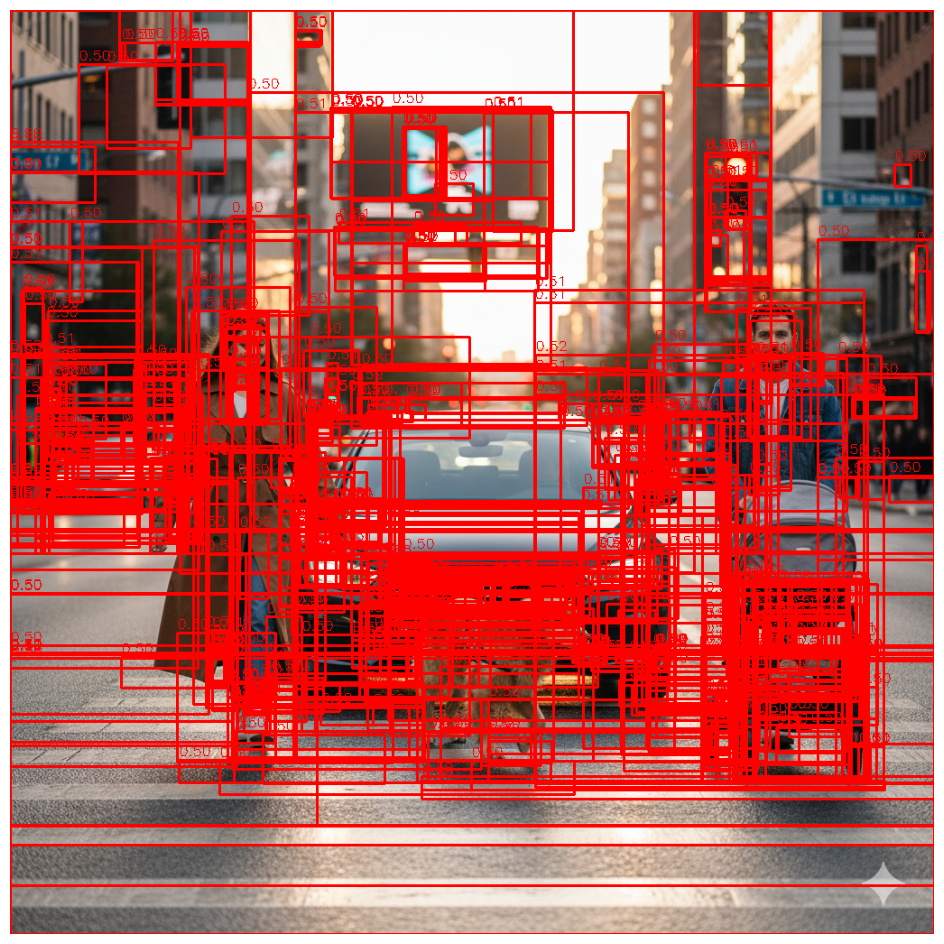

In [51]:
import matplotlib.pyplot as plt

draw = img_rgb.copy()

for (x1, y1, x2, y2, score) in proposals:
    cv2.rectangle(draw, (x1, y1), (x2, y2), (255,0,0), 2)
    cv2.putText(draw, f"{score:.2f}", (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

plt.figure(figsize=(12,12))
plt.imshow(draw)
plt.axis("off")
